# Regression using Deep Neural Networks

## Load Dataset from sklearn

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

In [8]:
df = pd.read_csv("../datasets/Boston_house.csv")

In [9]:
df.tail()

,AGE,B,RM,CRIM,DIS,INDUS,LSTAT,NOX,PTRATIO,RAD,ZN,TAX,CHAS,Target
501,69.1,391.99,6.593,0.06263,2.4786,11.93,9.67,0.573,21.0,1,0.0,273,0,22.4
502,76.7,396.90,6.120,0.04527,2.2875,11.93,9.08,0.573,21.0,1,0.0,273,0,20.6
503,91.0,396.90,6.976,0.06076,2.1675,11.93,5.64,0.573,21.0,1,0.0,273,0,23.9
504,89.3,393.45,6.794,0.10959,2.3889,11.93,6.48,0.573,21.0,1,0.0,273,0,22.0
505,80.8,396.90,6.030,0.04741,2.5050,11.93,7.88,0.573,21.0,1,0.0,273,0,11.9


## Train Model with PyTorch

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [11]:
data = torch.from_numpy(df.values).float()

data.shape

torch.Size([506, 14])

In [12]:
y = data[:, -1:]
x = data[:, :-1]

print(x.shape, y.shape)

torch.Size([506, 13]) torch.Size([506, 1])


In [13]:
n_epochs = 100000
learning_rate = 1e-4
print_interval = 5000

## Build Models

### Build Model using nn.Module

In [14]:
relu = nn.ReLU()
leaky_relu = nn.LeakyReLU(0.1)

In [15]:
class MyModel(nn.Module):

    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim

        super().__init__()

        self.linear1 = nn.Linear(input_dim, 3)
        self.linear2 = nn.Linear(3, 3)
        self.linear3 = nn.Linear(3, output_dim)
        self.act = nn.ReLU()

    def forward(self, x):
        h = self.act(self.linear1(x))
        h = self.act(self.linear2(h))
        y = self.linear3(h)

        return y

model = MyModel(x.size(-1), y.size(-1))

model

MyModel(
  (linear1): Linear(in_features=13, out_features=3, bias=True)
  (linear2): Linear(in_features=3, out_features=3, bias=True)
  (linear3): Linear(in_features=3, out_features=1, bias=True)
  (act): ReLU()
)

### Build Model with LeakyReLU using nn.Sequential

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [17]:
for i in range(n_epochs):
    y_hat = model(x)
    loss = F.mse_loss(y_hat, y)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    if (i + 1) % print_interval == 0:
        print('Epoch %d: loss=%.4e' % (i + 1, float(loss)))

/var/folders/dq/_14lk5f97lq0g0cyd0qw13t80000gn/T/ipykernel_33800/2005387713.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  print('Epoch %d: loss=%.4e' % (i + 1, float(loss)))


Epoch 5000: loss=7.5321e+01
Epoch 10000: loss=5.9928e+01
Epoch 15000: loss=5.0842e+01
Epoch 20000: loss=4.4299e+01
Epoch 25000: loss=3.9907e+01
Epoch 30000: loss=3.6576e+01
Epoch 35000: loss=3.4076e+01
Epoch 40000: loss=3.1901e+01
Epoch 45000: loss=3.0027e+01
Epoch 50000: loss=2.8767e+01
Epoch 55000: loss=2.7751e+01
Epoch 60000: loss=2.6866e+01
Epoch 65000: loss=2.6428e+01
Epoch 70000: loss=2.6030e+01
Epoch 75000: loss=2.5925e+01
Epoch 80000: loss=2.5585e+01
Epoch 85000: loss=2.5049e+01
Epoch 90000: loss=2.4734e+01
Epoch 95000: loss=2.4638e+01
Epoch 100000: loss=2.4243e+01


## Let's see the result!

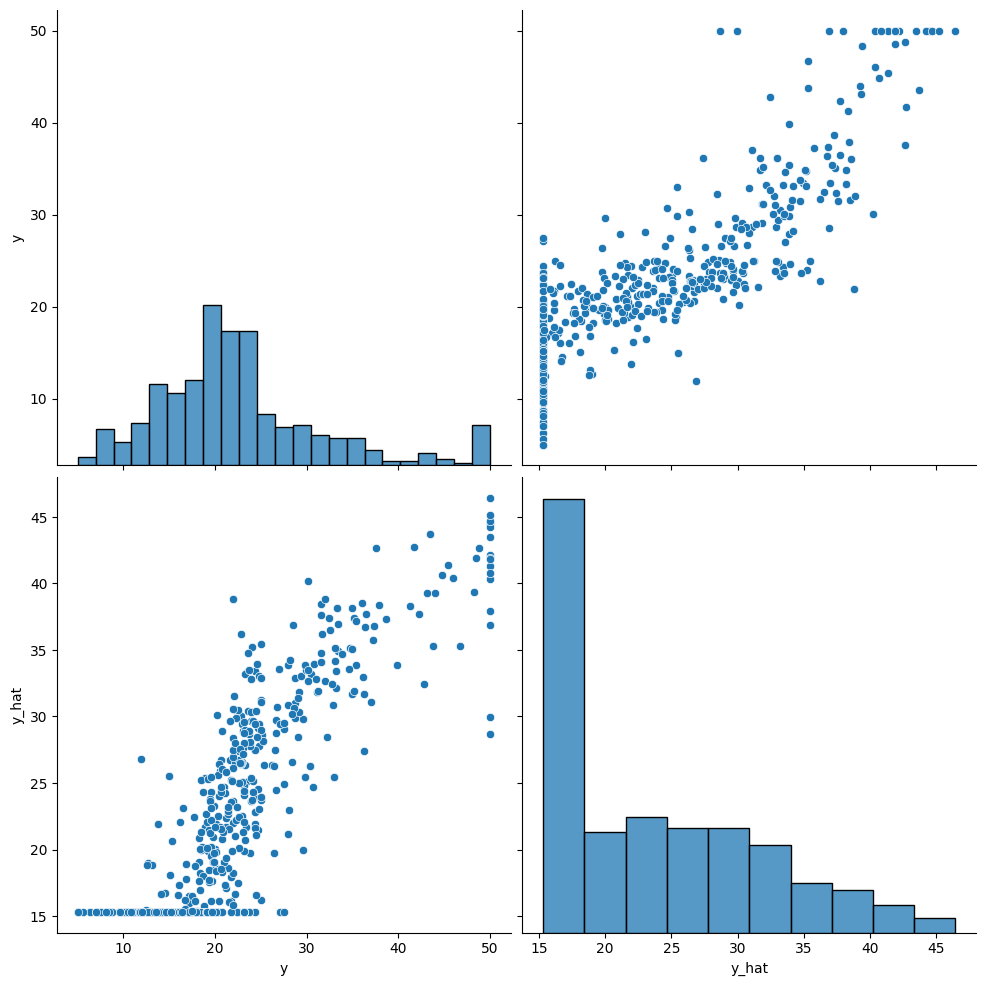

In [ ]:
df = pd.DataFrame(torch.cat([y, y_hat], dim=1).detach().numpy(), columns=["y", "y_hat"])

sns.pairplot(df, height=5)
plt.show()